## install DagsHub

In [ ]:
%pip install -q dagshub mlflow

## Imports

In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

import mlflow
import dagshub
from dagshub.upload import Repo


## Environment Check
Verify TensorFlow version and GPU availability before training.

In [ ]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
Keras version: 3.13.2
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download and Extract Dataset
Download the dataset archive and extract it into the working directory.

In [ ]:
def get_data_extract():
  if "dataset" in os.listdir():
    print("Dataset already exists")
  else:
    print("Downloading the data...")
    !wget -O food-data.zip https://www.kaggle.com/api/v1/datasets/download/trolukovich/food11-image-dataset
    print("Dataset downloaded!")
    print("Extracting data..")
    !mkdir dataset
    !unzip -q food-data.zip -d dataset
    print("Extraction done!")

get_data_extract()

Dataset already exists


## Dataset

Create Dataset from list of path

In [ ]:
dataset_root = Path("dataset")

for item in sorted(dataset_root.iterdir()):
    print(item)

dataset/evaluation
dataset/training
dataset/validation


In [ ]:
#اشتغلت صح وانحفظت البيانات بس لان اعدت تشغيل النوتبوك مارجعت شغلتها لان تاخذ وقت طويييل
repo = Repo("ahad-m", "my-first-repo")

# رفع مجلد الداتاسيت ل DAGsHub Storage
repo.upload("dataset", "dataset", versioning="dvc", force=True)
print("Dataset uploaded to DAGsHub")

Define Dataset Split Paths
Set the paths for the training, validation, and evaluation folders.

In [ ]:
train_dir = dataset_root / "training"
val_dir = dataset_root / "validation"
test_dir = dataset_root / "evaluation"

print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Train directory: dataset/training
Validation directory: dataset/validation
Test directory: dataset/evaluation


Inspect Class Names
Read the class folders from the training split and verify the number of classes.

In [ ]:
class_names = sorted([item.name for item in train_dir.iterdir() if item.is_dir()])
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Number of classes: 11


 تحميل الصور ك Datasets
- تستخدم (image_dataset_from_directory) لتحويل مجلدات الصور إلى داتاسيتات TensorFlow
- الإعدادات:
- حجم الصورة:260*260 (لأن بستخدم اصدار EfficientNetB2)
- الليبلات تستنتج تلقائي من أسماء المجلدات
- بيانات التدريب تنخلط عشوائيا

In [ ]:
IMG_SIZE = (260, 260)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Found 9866 files belonging to 11 classes.
Found 3430 files belonging to 11 classes.
Found 3347 files belonging to 11 classes.


visualize Sample Training Images
Display a batch of images and labels from the training dataset to verify loading and class mapping.

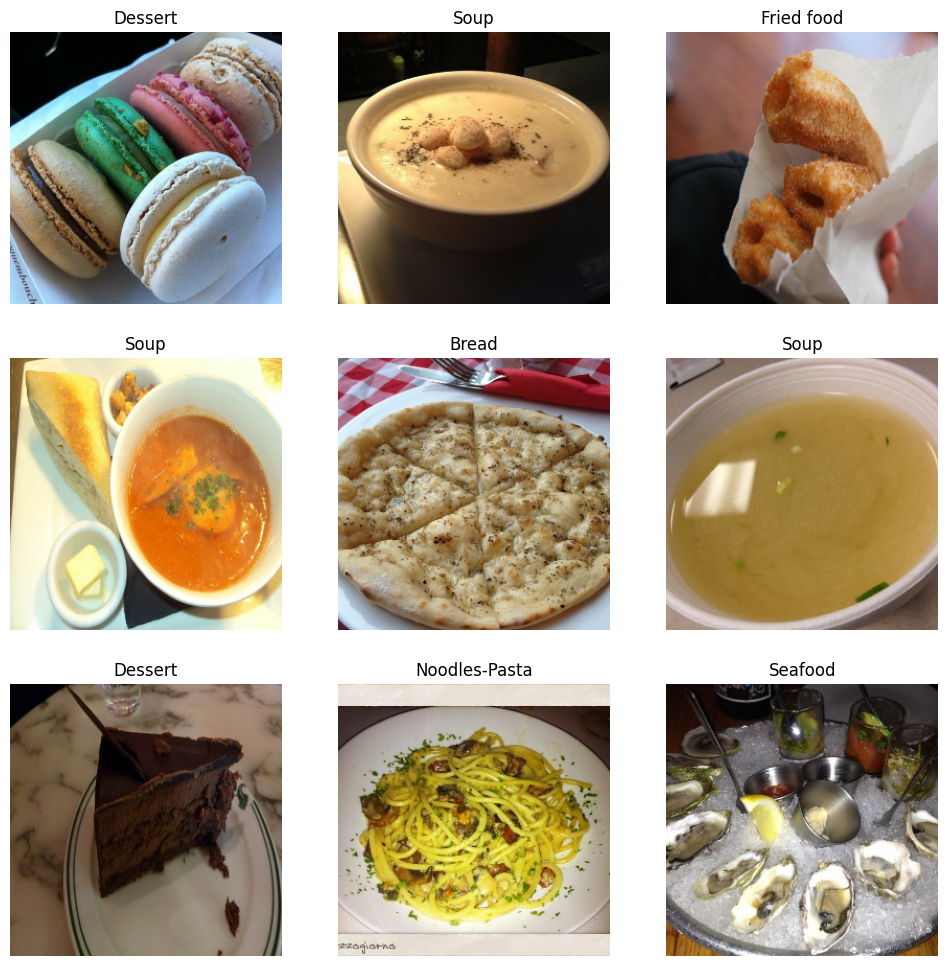

In [ ]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

plt.show()

## Data Augmentation and Preprocessing
Apply augmentation to training images only, and prepare inputs for EfficientNet.

In [ ]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
], name="data_augmentation")

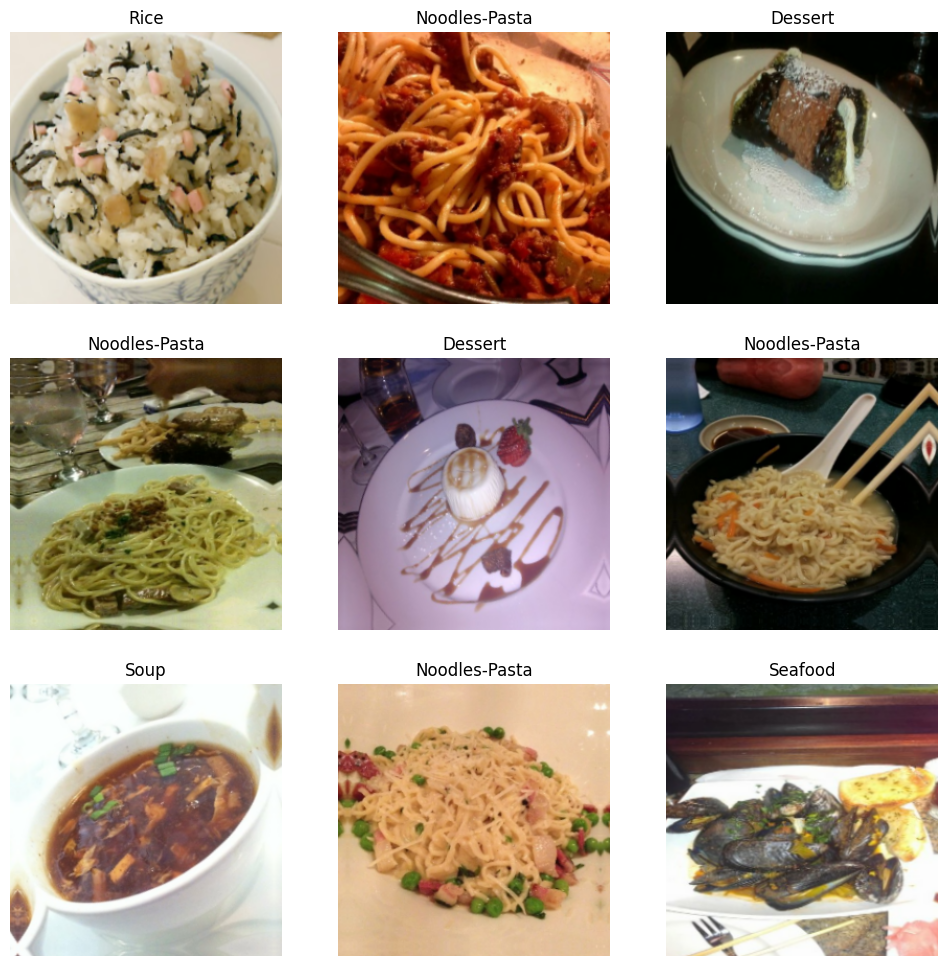

In [ ]:
sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 12))
for i in range(9):
    augmented_image = data_augmentation(sample_images[i:i+1], training=True)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title(class_names[sample_labels[i].numpy()])
    plt.axis("off")

plt.show()

# Model EfficientNetB0

In [ ]:
MODEL_NAME = "EfficientNetB2"

FEATURE_EXTRACTION_EPOCHS = 10
FINE_TUNING_EPOCHS = 10

FEATURE_EXTRACTION_LR = 1e-3
FINE_TUNING_LR = 1e-5

UNFREEZE_LAST_N_LAYERS = 20

DROPOUT_RATE = 0.2
PATIENCE = 5         # لل EarlyStopping
AUTOTUNE = tf.data.AUTOTUNE  #AUTOTUNE يخلي TensorFlow يقرر حجم الـ buffer المثالي تلقائى.

document model version


In [ ]:
print(f"Model: {MODEL_NAME}")

Model: EfficientNetB2


**تسريع تحميل البيانات**
- ثلاث تحسينات على الداتاسيتات عشان التدريب يكون أسرع
  - `cache()` : تخزن البيانات في الذاكرة بعد أول قراءة بدال ما يقرأها من جديد كل مرة
  - `shuffle(1000)` : تخلط بيانات التدريب عشوائياً (بس التدريب مو التحقق والاختبار)
  - `prefetch(AUTOTUNE)` : تجهز الدفعة الجاية بينما النموذج يتدرب على الحالية (عشان اوفر وقت الانتظار)


In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

 الربط مع DAGsHub / MLflow

In [ ]:
dagshub.init(repo_owner='ahad-m', repo_name='my-first-repo', mlflow=True)
mlflow.set_experiment("food11-efficientnet-transfer-learning")

Accessing as ahad-m

Initialized MLflow to track repo "ahad-m/my-first-repo"

Repository ahad-m/my-first-repo initialized!

<Experiment: artifact_location='mlflow-artifacts:/c178323fe0d6457d87ded9e6b355b582', creation_time=1773442511125, experiment_id='0', last_update_time=1773442511125, lifecycle_stage='active', name='food11-efficientnet-transfer-learning', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

## feature extraction model

Experiment 1: Feature Extraction
Train a new classification head on top of a frozen EfficientNet backbone.

In [ ]:
base_modelB2 = keras.applications.EfficientNetB2(include_top=False,weights="imagenet",input_shape=IMG_SIZE + (3,),)
#اجمد كل طبقات النموذج الاساسي
base_modelB2.trainable = False
#بناء الطبقات الجديدة (الهيد للتصنيف)
inputs  = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_modelB2(x, training=False) #يمرر الصور على النموذج الجاهز عشان يستخرج الفيتشرز
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(DROPOUT_RATE)(x)
outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

feature_extraction_modelB2 = keras.Model(inputs, outputs, name="feature_extraction_model")# اربط الهيد مع المودل الاساسي

In [ ]:
trainable = sum([tf.size(w).numpy() for w in feature_extraction_modelB2.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in feature_extraction_modelB2.non_trainable_weights])
print(f"Trainable params: {trainable:,}")
print(f"Non-trainable params: {non_trainable:,}")

Trainable params: 15,499
Non-trainable params: 7,768,569


In [ ]:
feature_extraction_modelB2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FEATURE_EXTRACTION_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_fe = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    mlflow.keras.MlflowCallback(),   # يسجل كل epoch تلقائياً
]

feature_extraction_modelB2.summary()

Model: "feature_extraction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        15,499 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,784,068 (29.69 MB)

 Trainable params: 15,499 (60.54 KB)

 Non-trainable params: 7,768,569 (29.63 MB)

In [ ]:
with mlflow.start_run(run_name="feature_extractionB2"):
    mlflow.log_params({
        "model_name"    : MODEL_NAME,
        "strategy"      : "feature_extraction",
        "img_size"      : IMG_SIZE[0],
        "batch_size"    : BATCH_SIZE,
        "epochs"        : FEATURE_EXTRACTION_EPOCHS,
        "learning_rate" : FEATURE_EXTRACTION_LR,
        "num_classes"   : num_classes,
        "dropout_rate"  : DROPOUT_RATE,
        "optimizer"     : "Adam",
    })

    feature_extraction_historyB2 = feature_extraction_modelB2.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FEATURE_EXTRACTION_EPOCHS,
        callbacks=callbacks_fe,
    )

    # Evaluate on test set
    feature_extraction_resultsB2 = feature_extraction_modelB2.evaluate(test_ds, verbose=1)
    mlflow.log_metric("test_loss",feature_extraction_resultsB2[0])
    mlflow.log_metric("test_accuracy",feature_extraction_resultsB2[1])
    from sklearn.metrics import classification_report, f1_score
    import numpy as np

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = feature_extraction_modelB2.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

    f1 = f1_score(y_true, y_pred, average="weighted")
    mlflow.log_metric("test_f1_weighted", f1)
    mlflow.keras.log_model(feature_extraction_modelB2, "model")


    print(f"Test Accuracy: {feature_extraction_resultsB2[1]:.4f}")
    print(f"Test Loss: {feature_extraction_resultsB2[0]:.4f}")


Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.7486 - loss: 0.8593 - val_accuracy: 0.8329 - val_loss: 0.5242 - learning_rate: 0.0010
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8378 - loss: 0.5001 - val_accuracy: 0.8539 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8605 - loss: 0.4322 - val_accuracy: 0.8606 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8692 - loss: 0.3964 - val_accuracy: 0.8627 - val_loss: 0.3988 - learning_rate: 0.0010
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8771 - loss: 0.3767 - val_accuracy: 0.8682 - val_loss: 0.3809 - learning_rate: 0.0010
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8829 - loss: 0.3477 - val_accuracy: 0.8749 - val_loss: 0.3632 - learning_rate: 0.0010
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8859 - loss: 0

2026/03/16 21:48:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


                 precision    recall  f1-score   support

          Bread       0.87      0.91      0.89       368
  Dairy product       0.88      0.76      0.81       148
        Dessert       0.90      0.86      0.88       500
            Egg       0.88      0.86      0.87       335
     Fried food       0.89      0.93      0.91       287
           Meat       0.91      0.94      0.93       432
  Noodles-Pasta       0.99      0.98      0.99       147
           Rice       0.96      0.99      0.97        96
        Seafood       0.92      0.87      0.89       303
           Soup       0.97      0.98      0.97       500
Vegetable-Fruit       0.92      0.98      0.95       231

       accuracy                           0.91      3347
      macro avg       0.92      0.91      0.91      3347
   weighted avg       0.91      0.91      0.91      3347



2026/03/16 21:48:25 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Test Accuracy: 0.9131
Test Loss: 0.2735
🏃 View run feature_extractionB2 at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0/runs/e69236956074484ca37357a74a48beae
🧪 View experiment at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0


Plot saved: feature_extraction_curvesB2.png


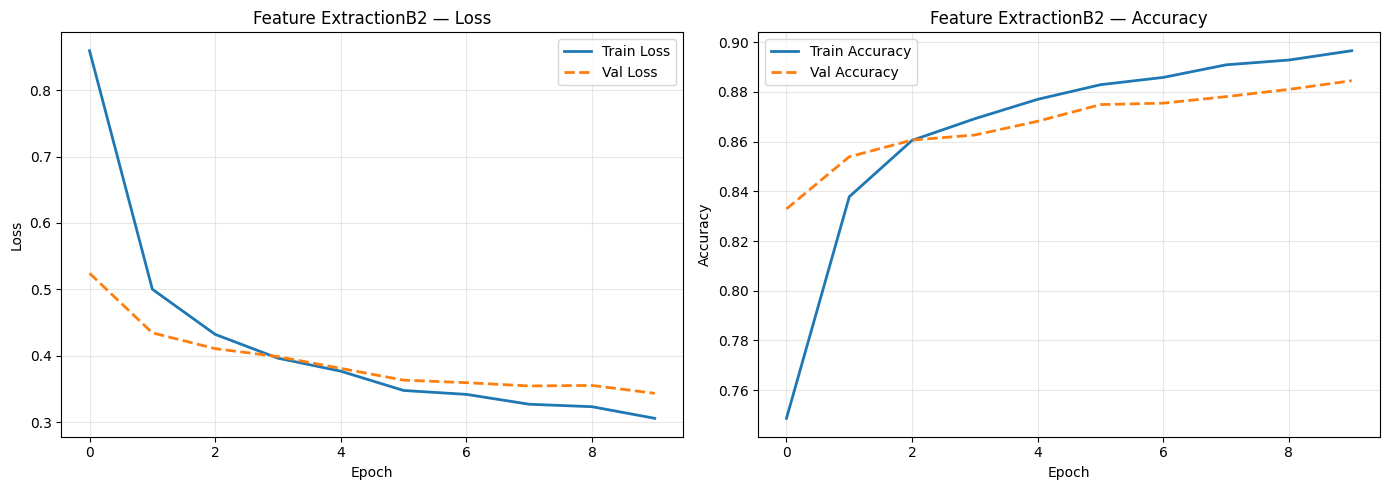

🏃 View run feature_extractionB2 at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0/runs/e69236956074484ca37357a74a48beae
🧪 View experiment at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0


In [ ]:
def plot_history(history, title_prefix, save_path=None):
    history_dict = history.history if hasattr(history, 'history') else history

    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history_dict["loss"],label="Train Loss",linewidth=2)
    plt.plot(history_dict["val_loss"],label="Val Loss",linewidth=2,linestyle="--")
    plt.title(f"{title_prefix} — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, alpha=0.3)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history_dict["accuracy"],label="Train Accuracy", linewidth=2)
    plt.plot(history_dict["val_accuracy"], label="Val Accuracy",linewidth=2,linestyle="--")
    plt.title(f"{title_prefix} — Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved: {save_path}")

    plt.show()

# رسم Feature Extraction
plot_history(
    feature_extraction_historyB2,
    title_prefix="Feature ExtractionB2",
    save_path="feature_extraction_curvesB2.png"   # يحفظ ويرفع ل MLflow
)

with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_artifact("feature_extraction_curvesB2.png")

 Analysis: Feature Extraction (EfficientNetB2)

**Results:** Accuracy = 91.31%, Loss = 0.2735, Weighted F1 = 0.91

Strongest classes: Noodles-Pasta (F1=0.99), Soup (0.97), Rice (0.97), distinct visual patterns. Weakest: Dairy product (F1=0.81, recall=0.76) ,visually diverse category often confused with Dessert and Egg. B2 outperformed B0 (89.60%) and B1 (90.89%) due to larger backbone and higher resolution (260×260).


## Fine Tuning (UNFREEZE LAST N LAYERS)

B2 has the same number of layers as B1 (340) because EfficientNet scales width (filters per layer) and resolution between versions, not depth. B2 uses 10% wider filters and 260×260 input, resulting in 7.8M parameters vs 6.5M for B1.

In [ ]:
print(len(base_modelB2.layers))

340


فك تجميد اخر 20 طبقة

In [ ]:
base_modelB2.trainable = True
for layer in base_modelB2.layers[:-UNFREEZE_LAST_N_LAYERS]:
    layer.trainable = False

**تجميد طبقات BatchNormalization**

ليه اجمدها؟ لأن BatchNorm تعتمد على إحصائيات (متوسط وتباين) محسوبة من ملايين صور. لو فتحتها على بياناتي القليله بتخرب هالإحصائيات وتأثر على الأداء سلبيا. هذي نصيحة معروفه في Transfer Learning.

In [ ]:
for layer in base_modelB2.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

 اتأكد إن التجميد وفك التجميد اشتغل صح

In [ ]:
trainable_layers = [l for l in base_modelB2.layers if l.trainable]
frozen_layers = [l for l in base_modelB2.layers if not l.trainable]

print(f"Trainable layers in base model B2: {len(trainable_layers)}")
print(f"Frozen layers in base model B2: {len(frozen_layers)}")
print(f"\nFirst unfrozen layer B2: {trainable_layers[0].name}")
print(f"Last unfrozen layer B2: {trainable_layers[-1].name}")

Trainable layers in base model B2: 15
Frozen layers in base model B2: 325

First unfrozen layer B2: block7a_project_conv
Last unfrozen layer B2: top_activation


In [ ]:
trainable_params = sum([tf.size(w).numpy() for w in feature_extraction_modelB2.trainable_weights])
print(f"\nTotal trainable parameters: {trainable_params:,}")


Total trainable parameters: 2,830,179


ليه استخدمت نفس النموذج اللي دربته قبل ؟


الطبقات الجديدة (الهيد التصنيفات) متعلمة اصلا في المرحلة الأولى ف مايحتاج ارجع ادربها من الصفر

In [ ]:
fine_tuning_modelB2 = feature_extraction_modelB2

fine_tuning_modelB2.compile(optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNING_LR),loss="sparse_categorical_crossentropy",metrics=["accuracy"],)

callbacks_ft = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    mlflow.keras.MlflowCallback(),
]

print("Fine-tuning model compiled")
print(f"LR = {FINE_TUNING_LR}")
fine_tuning_modelB2.summary()

Fine-tuning model compiled
LR = 1e-05


Model: "feature_extraction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        15,499 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,784,068 (29.69 MB)

 Trainable params: 2,830,179 (10.80 MB)

 Non-trainable params: 4,953,889 (18.90 MB)

In [ ]:
with mlflow.start_run(run_name="fine_tuning_last_N_layersB2"):
    mlflow.log_params({
        "model_name"            : MODEL_NAME,
        "strategy"              : "fine_tuning_last_N_layers",
        "img_size"              : IMG_SIZE[0],
        "batch_size"            : BATCH_SIZE,
        "epochs"                : FINE_TUNING_EPOCHS,
        "learning_rate"         : FINE_TUNING_LR,
        "num_classes"           : num_classes,
        "unfreeze_last_n_layers": UNFREEZE_LAST_N_LAYERS,
        "optimizer"             : "Adam",
        "bn_frozen"             : True,
    })

    fine_tuning_historyB2 = fine_tuning_modelB2.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FEATURE_EXTRACTION_EPOCHS + FINE_TUNING_EPOCHS,  # 20 إجمالاً
        initial_epoch=FEATURE_EXTRACTION_EPOCHS,                  # ابدأ من 10
        callbacks=callbacks_ft,
    )

    # تقييم على test set
    fine_tuning_resultsB2 = fine_tuning_modelB2.evaluate(test_ds, verbose=1)
    mlflow.log_metric("test_loss", fine_tuning_resultsB2[0])
    mlflow.log_metric("test_accuracy", fine_tuning_resultsB2[1])
       # Evaluate on test set
    from sklearn.metrics import classification_report, f1_score
    import numpy as np

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = fine_tuning_modelB2.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

    f1 = f1_score(y_true, y_pred, average="weighted")
    mlflow.log_metric("test_f1_weighted2", f1)
    mlflow.keras.log_model(fine_tuning_modelB2, "model")


    print(f"\nFine-tuning Test Accuracy B2: {fine_tuning_resultsB2[1]:.4f}")
    print(f"Fine-tuning Test Loss B2: {fine_tuning_resultsB2[0]:.4f}")
    print(f"\nImprovement over Feature Extraction B2:")
    print(f"Accuracy B2: {(fine_tuning_resultsB2[1] - feature_extraction_resultsB2[1])*100:+.2f}%")



Epoch 11/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9049 - loss: 0.2825 - val_accuracy: 0.8892 - val_loss: 0.3312 - learning_rate: 1.0000e-05
Epoch 12/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9054 - loss: 0.2748 - val_accuracy: 0.8918 - val_loss: 0.3223 - learning_rate: 1.0000e-05
Epoch 13/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9128 - loss: 0.2607 - val_accuracy: 0.8945 - val_loss: 0.3155 - learning_rate: 1.0000e-05
Epoch 14/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9164 - loss: 0.2498 - val_accuracy: 0.8942 - val_loss: 0.3136 - learning_rate: 1.0000e-05
Epoch 15/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9214 - loss: 0.2348 - val_accuracy: 0.9017 - val_loss: 0.3054 - learning_rate: 1.0000e-05
Epoch 16/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9214 - loss: 0.2309 - val_accuracy: 0.8997 - val_loss: 0.3029 - learning_rate: 1.0000e-05
Epoch 17/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/st

2026/03/16 21:51:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


                 precision    recall  f1-score   support

          Bread       0.91      0.92      0.91       368
  Dairy product       0.91      0.80      0.85       148
        Dessert       0.89      0.89      0.89       500
            Egg       0.92      0.90      0.91       335
     Fried food       0.92      0.92      0.92       287
           Meat       0.94      0.95      0.94       432
  Noodles-Pasta       0.99      0.98      0.98       147
           Rice       0.97      0.99      0.98        96
        Seafood       0.90      0.93      0.92       303
           Soup       0.98      0.98      0.98       500
Vegetable-Fruit       0.95      0.98      0.97       231

       accuracy                           0.93      3347
      macro avg       0.93      0.93      0.93      3347
   weighted avg       0.93      0.93      0.93      3347



2026/03/16 21:51:21 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



Fine-tuning Test Accuracy B2: 0.9304
Fine-tuning Test Loss B2: 0.2213

Improvement over Feature Extraction B2:
Accuracy B2: +1.73%
🏃 View run fine_tuning_last_N_layersB2 at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0/runs/2fe0e0b5668b49bcbf089ac727956b3c
🧪 View experiment at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0


Plot saved: fine_tuning_curvesB2.png


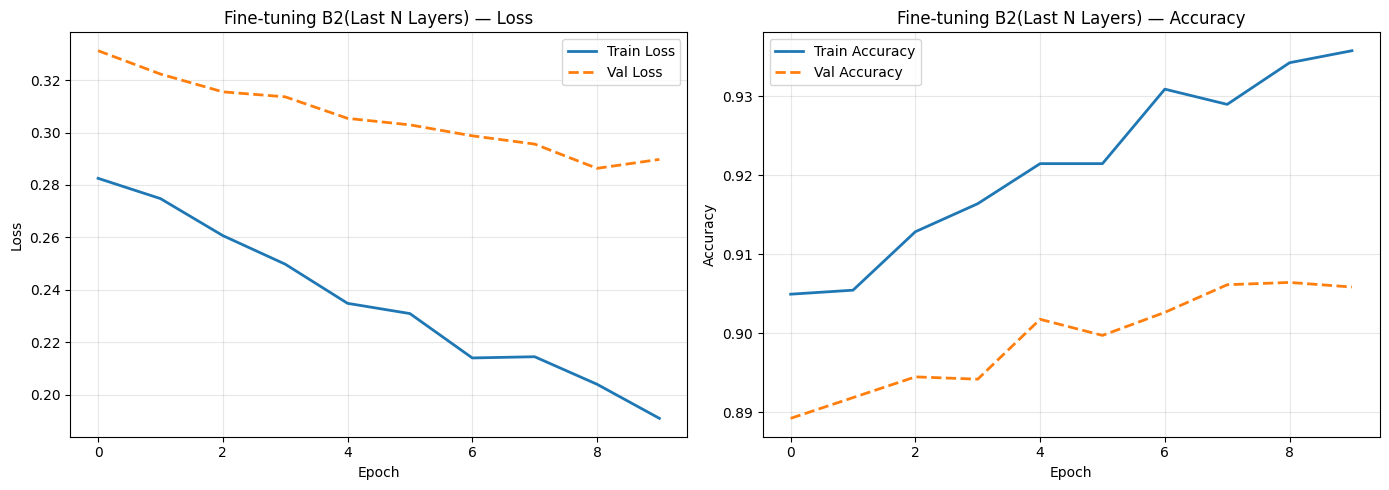

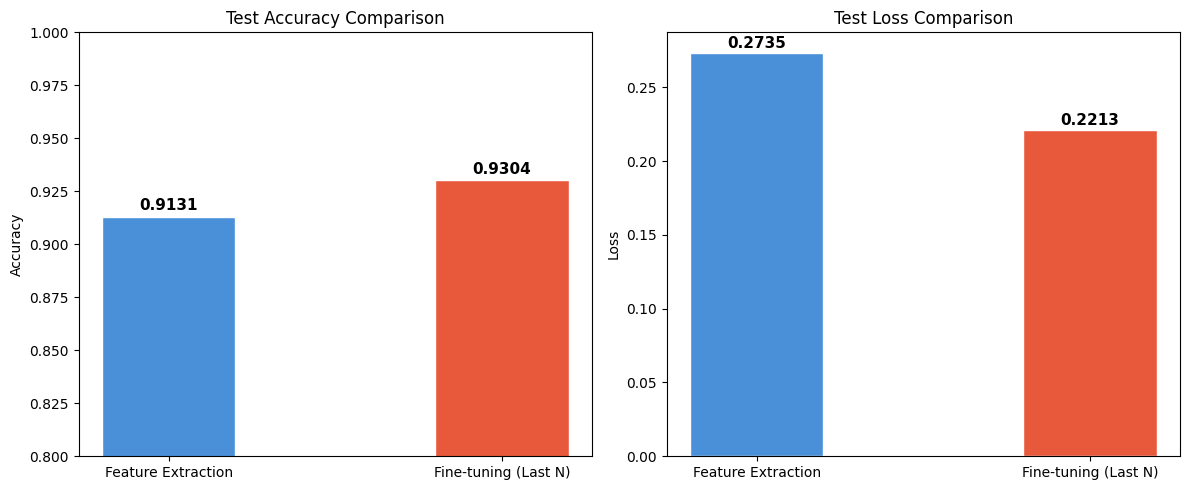

🏃 View run fine_tuning_last_N_layersB2 at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0/runs/2fe0e0b5668b49bcbf089ac727956b3c
🧪 View experiment at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0
Plots saved and uploaded to MLflow


In [ ]:
plot_history(
    fine_tuning_historyB2,
    title_prefix="Fine-tuning B2(Last N Layers)",
    save_path="fine_tuning_curvesB2.png"
)

#  مقارنة بين النموذجين
strategies  = ["Feature Extraction", "Fine-tuning (Last N)"]
test_accs   = [feature_extraction_resultsB2[1], fine_tuning_resultsB2[1]]
test_losses = [feature_extraction_resultsB2[0], fine_tuning_resultsB2[0]]
colors      = ["#4A90D9", "#E8593C"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
axes[0].bar(strategies, test_accs, color=colors, width=0.4, edgecolor="white")
axes[0].set_title("Test Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.8, 1.0)
for i, v in enumerate(test_accs):
    axes[0].text(i, v + 0.003, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

# Loss comparison
axes[1].bar(strategies, test_losses, color=colors, width=0.4, edgecolor="white")
axes[1].set_title("Test Loss Comparison")
axes[1].set_ylabel("Loss")
for i, v in enumerate(test_losses):
    axes[1].text(i, v + 0.003, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("comparison_fe_vs_ftB2.png", dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_artifact("fine_tuning_curvesB2.png")
    mlflow.log_artifact("comparison_fe_vs_ftB2.png")

print("Plots saved and uploaded to MLflow")

Analysis: Fine-tuning EfficientNetB2

**Results:** Accuracy = 93.04%, Loss = 0.2213, Weighted F1 = 0.93 | +1.73% over FE

Weakest classes improved most: Dairy (F1: 0.81→0.85), Egg (0.87→0.91), Seafood (0.89→0.92). Already-strong classes (Noodles-Pasta, Soup) stayed near-perfect. Unfreezing the top layers helped the model learn food-specific features for visually similar categories.


## Gradual Unfreezing

هذي خليتين استكشافيتين عشان افهم التركيب الداخلي لنموذج EfficientNet

In [ ]:
for i, layer in enumerate(base_modelB2.layers):
    print(f"{i:3d} | {layer.name}")

  0 | input_layer_1
  1 | rescaling
  2 | normalization
  3 | rescaling_1
  4 | stem_conv_pad
  5 | stem_conv
  6 | stem_bn
  7 | stem_activation
  8 | block1a_dwconv
  9 | block1a_bn
 10 | block1a_activation
 11 | block1a_se_squeeze
 12 | block1a_se_reshape
 13 | block1a_se_reduce
 14 | block1a_se_expand
 15 | block1a_se_excite
 16 | block1a_project_conv
 17 | block1a_project_bn
 18 | block1b_dwconv
 19 | block1b_bn
 20 | block1b_activation
 21 | block1b_se_squeeze
 22 | block1b_se_reshape
 23 | block1b_se_reduce
 24 | block1b_se_expand
 25 | block1b_se_excite
 26 | block1b_project_conv
 27 | block1b_project_bn
 28 | block1b_drop
 29 | block1b_add
 30 | block2a_expand_conv
 31 | block2a_expand_bn
 32 | block2a_expand_activation
 33 | block2a_dwconv_pad
 34 | block2a_dwconv
 35 | block2a_bn
 36 | block2a_activation
 37 | block2a_se_squeeze
 38 | block2a_se_reshape
 39 | block2a_se_reduce
 40 | block2a_se_expand
 41 | block2a_se_excite
 42 | block2a_project_conv
 43 | block2a_project_bn

In [ ]:
block_prefixes = [
    "block1", "block2", "block3", "block4",
    "block5", "block6", "block7", "top",
]

for prefix in block_prefixes:
    layers = [l for l in base_modelB2.layers if l.name.startswith(prefix)]
    print(f"{prefix:10s} → {len(layers):2d} طبقة | "
          f"أول: {layers[0].name:35s} | "
          f"آخر: {layers[-1].name}")

block1     → 22 طبقة | أول: block1a_dwconv                      | آخر: block1b_add
block2     → 44 طبقة | أول: block2a_expand_conv                 | آخر: block2c_add
block3     → 44 طبقة | أول: block3a_expand_conv                 | آخر: block3c_add
block4     → 59 طبقة | أول: block4a_expand_conv                 | آخر: block4d_add
block5     → 58 طبقة | أول: block5a_expand_conv                 | آخر: block5d_add
block6     → 74 طبقة | أول: block6a_expand_conv                 | آخر: block6e_add
block7     → 28 طبقة | أول: block7a_expand_conv                 | آخر: block7b_add
top        →  3 طبقة | أول: top_conv                            | آخر: top_activation


ليه نموذج جديد؟

النموذج الاول (feature_extraction_model) جربت عليه استراتيجية "فك اخر 20 طبقة دفعة وحدة" هالنموذج الجديد بيجرب فك التجميد تدريجيا بلوك بلوك عشان اقارن اي استراتيجية احسن

In [ ]:
base_model_gradB2 = keras.applications.EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)
base_model_gradB2.trainable = False

inputs_grad = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs_grad)
x = base_model_gradB2(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(DROPOUT_RATE)(x)
outputs_grad = keras.layers.Dense(num_classes, activation="softmax")(x)

gradual_modelB2 = keras.Model(inputs_grad, outputs_grad,name="gradual_unfreezing_modelB2")

In [ ]:
# تحقق
total = len(base_model_gradB2.layers)
frozen = len([l for l in base_model_gradB2.layers if not l.trainable])
print(f"Total layers  : {total}")
print(f"Frozen layers : {frozen}")

Total layers  : 340
Frozen layers : 340


**دالة فك التجميد التدريجي + تطبيقها على Block7**
- تعريف دالة `unfreeze_block` تفك تجميد بلوك واحد مع تجميد BatchNorm وإعادة compile
- الفكرة: فك التجميد **تدريجياً من الأخير للأول** بدال دفعة وحدة


 ليه نبدأ من الأخير؟ لأن الطبقات الأخيرة هي الأقرب للمخرجات افكها أول شي

In [ ]:
def unfreeze_block(model, base, prefix, current_lr):

    layers_to_unfreeze = [l for l in base.layers if l.name.startswith(prefix)]

    for layer in layers_to_unfreeze:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=current_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    unfrozen = [
        l for l in base.layers
        if l.trainable and not isinstance(l, keras.layers.BatchNormalization)
    ]
    bn_frozen = [
        l for l in base.layers
        if isinstance(l, keras.layers.BatchNormalization)
    ]
    print(f"فتحت : {prefix:10s} | "
          f"trainable: {len(unfrozen):3d} | "
          f"BN مجمدة: {len(bn_frozen):3d} | "
          f"LR: {current_lr:.0e}")

unfreeze_block(gradual_modelB2, base_model_gradB2, "block7", 1e-4)

block7_layers = [l for l in base_model_gradB2.layers if l.name.startswith("block7")]
non_block7_layers = [l for l in base_model_gradB2.layers if not l.name.startswith("block7")]

print(f"\block7 trainable : {sum(l.trainable for l in block7_layers)}/{len(block7_layers)}")
print(f"blocks frozen: {sum(not l.trainable for l in non_block7_layers)}/{len(non_block7_layers)}")

فتحت : block7     | trainable:  22 | BN مجمدة:  69 | LR: 1e-04
lock7 trainable : 22/28
blocks frozen: 312/312


 تدريب بفك تجميد تدريجي (Gradual Unfreezing)
- استراتيجية ثالثة:
افك التجميد **بلوك بلوك** من الأخير للأول
- كل بلوك يتدرّب **5 جولات**، ومعدل التعلم **يتقلّص بـ 0.7** بعد كل بلوك
- الفكرة: الطبقات العميقة تحتاج خطوات أصغر لأن ميزاتها أعم وأهم

In [ ]:
EPOCHS_PER_BLOCK = 5 #كل بلوك ياخذ5 جولاتتدريب قبل ما نفك البلوك اللي بعده. عشان النموذج ياخذ وقت يتأقلم على كل بلوك جديد.
GRAD_LR_START = 1e-4
LR_DECAY_FACTOR  = 0.7

# نبدأ بتدريب ال head فقط
gradual_modelB2.compile(optimizer=keras.optimizers.Adam(learning_rate=GRAD_LR_START),loss="sparse_categorical_crossentropy",metrics=["accuracy"],)

# blocks من الأخير للأول
blocks_to_unfreeze = ["top", "block7", "block6", "block5","block4", "block3", "block2", "block1"]
#جمع سجل تدريب كل بلوك عشان نرسمها بعدين
all_histories = []
current_lr = GRAD_LR_START
current_epoch = 0

with mlflow.start_run(run_name="gradual_unfreezingB2"):
    mlflow.log_params({
        "model_name"       : MODEL_NAME,
        "strategy"         : "gradual_unfreezing",
        "epochs_per_block" : EPOCHS_PER_BLOCK,
        "lr_start"         : GRAD_LR_START,
        "lr_decay_factor"  : LR_DECAY_FACTOR,
        "bn_frozen"        : True,
    })
#يمر على كل بلوك ويسوي أربع خطوات
    for block_prefix in blocks_to_unfreeze:

        print(f"\n{'='*60}")
        print(f" فتح {block_prefix} — epoch {current_epoch+1} ل {current_epoch+EPOCHS_PER_BLOCK}")
        print(f"{'='*60}")
#1) تفك تجميد طبقات البلوك المحدد وتعيد compile بمعدل التعلم الجديد
        unfreeze_block(gradual_modelB2, base_model_gradB2, block_prefix, current_lr)
#2) التدريب
        historyB2 = gradual_modelB2.fit(
            train_ds,
            validation_data=val_ds,
            epochs=current_epoch + EPOCHS_PER_BLOCK,
            initial_epoch=current_epoch,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=4,
                    restore_best_weights=True,
                    verbose=0
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.5,
                    patience=2,
                    min_lr=1e-8,
                    verbose=0
                ),
                mlflow.keras.MlflowCallback(),
            ],
        )
#3) تسجيل النتايج
        all_histories.append(historyB2.history)
        current_epoch += EPOCHS_PER_BLOCK

        last_val_acc  = historyB2.history["val_accuracy"][-1]
        last_val_loss = historyB2.history["val_loss"][-1]
        print(f"val_accuracy : {last_val_acc:.4f}")
        print(f"val_loss : {last_val_loss:.4f}")
        from sklearn.metrics import classification_report, f1_score
        import numpy as np

        y_true, y_pred = [], []
        for images, labels in test_ds:
            preds = gradual_modelB2.predict(images, verbose=0)
            y_pred.extend(np.argmax(preds, axis=1))
            y_true.extend(labels.numpy())

        print(classification_report(y_true, y_pred, target_names=class_names))

        f1 = f1_score(y_true, y_pred, average="weighted")
        mlflow.log_metric("test_f1_weighted3", f1)
        mlflow.keras.log_model(gradual_modelB2, "model")


        current_lr = max(current_lr * LR_DECAY_FACTOR, 1e-7)
    print(f"\n{'='*60}")
    print("التقييم النهائي على Test Set")
    gradual_resultsB2 = gradual_modelB2.evaluate(test_ds, verbose=1)
    mlflow.log_metric("test_loss", gradual_resultsB2[0])
    mlflow.log_metric("test_accuracy", gradual_resultsB2[1])
    mlflow.keras.log_model(gradual_modelB2, "model")



 فتح top — epoch 1 ل 5
فتحت : top        | trainable:  24 | BN مجمدة:  69 | LR: 1e-04


Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.7693 - loss: 0.7323 - val_accuracy: 0.8828 - val_loss: 0.3703 - learning_rate: 1.0000e-04
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8904 - loss: 0.3403 - val_accuracy: 0.8895 - val_loss: 0.3589 - learning_rate: 1.0000e-04
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9202 - loss: 0.2552 - val_accuracy: 0.9131 - val_loss: 0.2861 - learning_rate: 1.0000e-04
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9382 - loss: 0.1899 - val_accuracy: 0.9105 - val_loss: 0.3003 - learning_rate: 1.0000e-04
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9470 - loss: 0.1576 - val_accuracy: 0.9160 - val_loss: 0.2939 - learning_rate: 1.0000e-04
val_accuracy : 0.9160
val_loss : 0.2939
                 precision    recall  f1-score   support

          Bread       0.85      0.95      0.90       368
  Dairy product       0.89      0.85      0.87       148
     

2026/03/16 21:53:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 21:53:30 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



 فتح block7 — epoch 6 ل 10
فتحت : block7     | trainable:  24 | BN مجمدة:  69 | LR: 7e-05


2026/03/16 21:53:45 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: INVALID_PARAMETER_VALUE: Response: {'error_code': 'INVALID_PARAMETER_VALUE'}


...

                 precision    recall  f1-score   support

          Bread       0.92      0.95      0.94       368
  Dairy product       0.93      0.88      0.90       148
        Dessert       0.93      0.93      0.93       500
            Egg       0.97      0.93      0.95       335
     Fried food       0.92      0.93      0.93       287
           Meat       0.96      0.95      0.95       432
  Noodles-Pasta       0.99      0.99      0.99       147
           Rice       0.98      1.00      0.99        96
        Seafood       0.94      0.97      0.95       303
           Soup       0.99      0.98      0.98       500
Vegetable-Fruit       0.96      0.99      0.97       231

       accuracy                           0.95      3347
      macro avg       0.95      0.95      0.95      3347
   weighted avg       0.95      0.95      0.95      3347



2026/03/16 22:08:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



التقييم النهائي على Test Set
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9513 - loss: 0.2164


2026/03/16 22:08:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 22:09:02 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run gradual_unfreezingB2 at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0/runs/5a6978e967e24be693bf1931f46a06b2
🧪 View experiment at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0


In [ ]:
print(f"المقارنة الكاملة:")
print(f"Feature Extraction : {feature_extraction_resultsB2[1]:.4f}")
print(f"Fine-tuning (Last N): {fine_tuning_resultsB2[1]:.4f}")
print(f"Gradual Unfreezing : {gradual_resultsB2[1]:.4f}")

المقارنة الكاملة:
Feature Extraction : 0.9131
Fine-tuning (Last N): 0.9304
Gradual Unfreezing : 0.9513


رسم النتائج والمقارنة النهائية

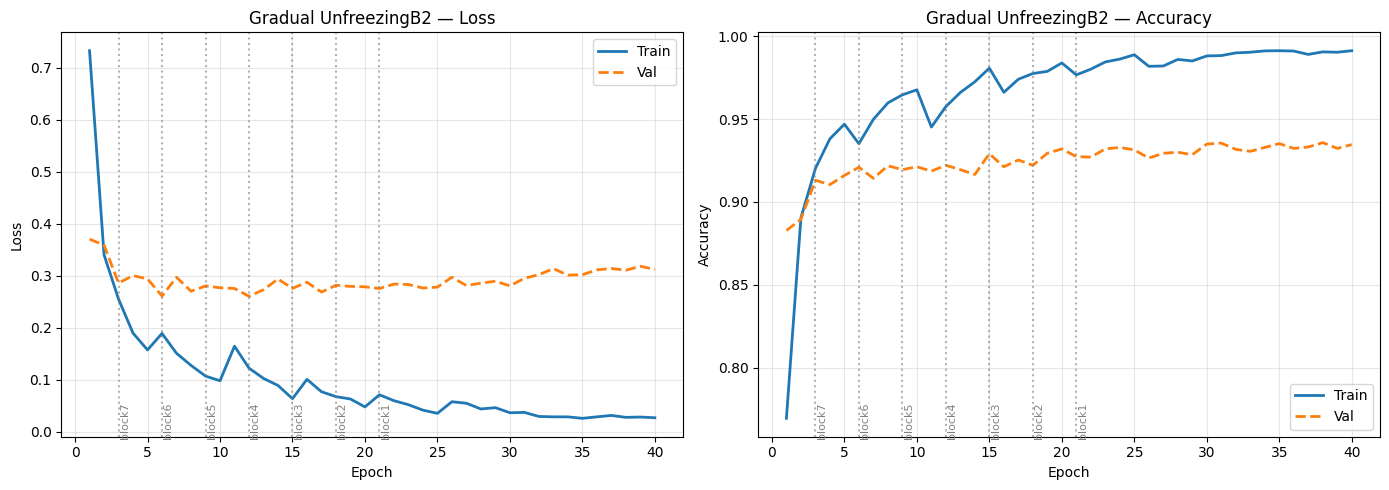

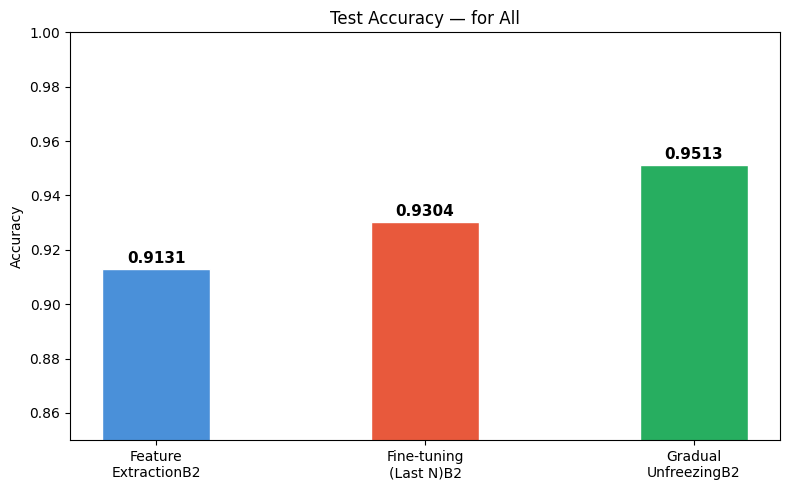

Plots saved


In [ ]:
#  دمج كل ال histories
combined = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
for h in all_histories:
    for key in combined:
        combined[key].extend(h.get(key, []))

epochs = range(1, len(combined["loss"]) + 1)

#  الرسم الأول: منحنيات ال Gradual Unfreezing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

block_labels = ["top", "block7", "block6", "block5",
                "block4", "block3", "block2", "block1"]
boundaries   = [i * 3 for i in range(1, 8)]  # 3, 6, 9, ...

for ax, (train_key, val_key, title) in zip(axes, [
    ("loss","val_loss","Loss"),
    ("accuracy","val_accuracy","Accuracy"),
]):
    ax.plot(epochs, combined[train_key], label="Train", linewidth=2)
    ax.plot(epochs, combined[val_key], label="Val",
            linewidth=2, linestyle="--")

    for i, b in enumerate(boundaries):
        ax.axvline(x=b,color="gray", linestyle=":", alpha=0.6)
        ax.text(b + 0.1,ax.get_ylim()[0],
                block_labels[i+1],fontsize=8,
                color="gray", rotation=90)

    ax.set_title(f"Gradual UnfreezingB2 — {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gradual_unfreezing_curvesB2.png", dpi=150, bbox_inches="tight")
plt.show()

#  الرسم الثاني: مقارنة الثلاث استراتيجيات
strategies = ["Feature\nExtractionB2", "Fine-tuning\n(Last N)B2", "Gradual\nUnfreezingB2"]
test_accs = [feature_extraction_resultsB2[1],fine_tuning_resultsB2[1],gradual_resultsB2[1],]
colors = ["#4A90D9", "#E8593C", "#27AE60"]

plt.figure(figsize=(8, 5))
bars = plt.bar(strategies, test_accs, color=colors,width=0.4, edgecolor="white")
plt.title("Test Accuracy — for All")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
for bar, val in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width() / 2,val + 0.002,f"{val:.4f}",ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("final_comparisonB2.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plots saved")

Analysis: Gradual Unfreezing EfficientNetB2

**Results:** Accuracy = 95.13%, Loss = 0.2164, Weighted F1 = 0.95 | Best strategy

All 11 classes now above F1=0.90. Biggest gains from FE: Dairy (+0.09, now 0.90), Egg (+0.08, now 0.95), Seafood (+0.06, now 0.95). Rice achieved perfect recall (1.00). Training accuracy ~99% vs validation ~93% shows some overfitting, but test F1=0.95 confirms strong generalization.

B2 slightly underperformed B1 here (95.13% vs 95.16%), confirming that with full fine-tuning, training strategy matters more than model size.


## Final Summary and Comparison


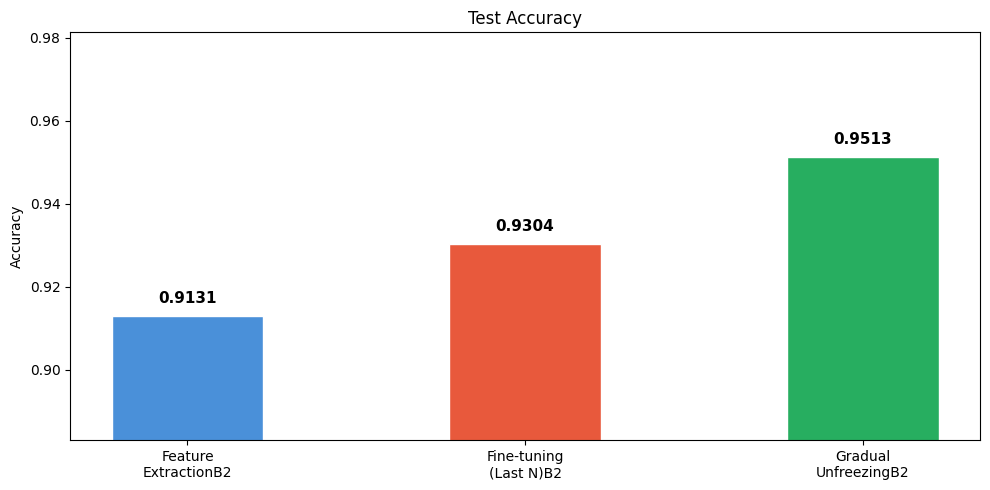

🏃 View run gradual_unfreezingB2 at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0/runs/5a6978e967e24be693bf1931f46a06b2
🧪 View experiment at: https://dagshub.com/ahad-m/my-first-repo.mlflow/#/experiments/0
Plots saved


In [ ]:

strategies = [
    "Feature\nExtractionB2",
    "Fine-tuning\n(Last N)B2",
    "Gradual\nUnfreezingB2",
]

test_accs = [
    feature_extraction_resultsB2[1],
    fine_tuning_resultsB2[1],
    gradual_resultsB2[1],
]

colors = ["#4A90D9", "#E8593C", "#27AE60", "#9B59B6"]

plt.figure(figsize=(10, 5))
bars = plt.bar(strategies, test_accs, color=colors,
               width=0.45, edgecolor="white")

plt.title("Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(min(test_accs) - 0.03, max(test_accs) + 0.03)

for bar, val in zip(bars, test_accs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.003,
        f"{val:.4f}",
        ha="center", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.savefig("final_comparison_allB2.png", dpi=150, bbox_inches="tight")
plt.show()


with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_artifact("final_comparison_allB2.png")

print("Plots saved")


 Accuracy: B0 vs B1 vs B2

| Strategy | B0 | B1 | B2 | B2 F1 |
|----------|:---:|:---:|:---:|:---:|
| Feature Extraction | 89.51% | 90.89% | **91.31%** | 0.91 |
| Fine-tuning | 91.28% | 92.50% | **93.04%** | 0.93 |
| Gradual Unfreezing | 94.71% | 95.01% | **95.13%** | **0.95** |
### F1-Score Progression Across Strategies (B2)

| Class | FE | FT | GU | Total Gain |
|-------|:---:|:---:|:---:|:---:|
| Dairy product | 0.81 | 0.85 | **0.90** | **+0.09** |
| Egg | 0.87 | 0.91 | **0.95** | **+0.08** |
| Seafood | 0.89 | 0.92 | **0.95** | +0.06 |
| Bread | 0.89 | 0.91 | **0.94** | +0.05 |
| Dessert | 0.88 | 0.89 | **0.93** | +0.05 |
| Fried food | 0.91 | 0.92 | 0.93 | +0.02 |
| Meat | 0.93 | 0.94 | **0.95** | +0.02 |
| Vegetable-Fruit | 0.95 | 0.97 | 0.97 | +0.02 |
| Rice | 0.97 | 0.98 | **0.99** | +0.02 |
| Soup | 0.97 | 0.98 | **0.98** | +0.01 |
| Noodles-Pasta | 0.99 | 0.98 | **0.99** | +0.00 |

### Key Findings

**Model size vs Strategy:** Larger models (B2) help most with frozen backbones ,FE accuracy: B0=89.60%, B2=91.31% (+1.71%). But with Gradual Unfreezing all three converge to ~95%, and B1 actually edges out B2 (95.16% vs 95.13%). Training strategy matters more than model size.

**Weakest classes improved most:** Dairy product gained +0.09 F1 (0.81→0.90) and Egg gained +0.08 (0.87→0.95) through progressive unfreezing. These visually diverse categories needed deeper feature adaptation.

**Strongest classes stayed strong:** Noodles-Pasta (0.99), Rice (0.99, perfect recall), and Soup (0.98) maintained near-perfect F1 across all strategies ,their visual features are distinct enough for even a frozen backbone.

**Overfitting:** Training accuracy reached ~99% vs validation ~93% in Gradual Unfreezing, but test F1=0.95 across all classes confirms the model generalizes well despite some memorization.

**Recommendation:** For quick deployment, B2 Feature Extraction gives the best frozen-backbone accuracy (91.31%). For maximum performance, Gradual Unfreezing with any model reaches ~95%. The extra training time of B2 over B0 is most justified in Feature Extraction and least justified in Gradual Unfreezing.